<a href="https://colab.research.google.com/github/fadmedh/Intel_Image_Classification_Project/blob/main/Intel_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install tensorflow

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense ,Dropout,BatchNormalization

Data collecting Using API

In [3]:
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
! kaggle datasets download -d blourdhuraju/intel-image-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/blourdhuraju/intel-image-classification-dataset
License(s): CC0-1.0
100% 243M/243M [00:07<00:00, 32.6MB/s]



In [5]:
import zipfile

with zipfile.ZipFile('intel-image-classification-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Done")

Done


In [6]:
train_data_dir='/content/dataset/Intel-Image-Classification/train'
test_data_dir='/content/dataset/Intel-Image-Classification/test'
valid_data_dir='/content/dataset/Intel-Image-Classification/val'

In [7]:
os.listdir(train_data_dir)

['forest', 'street', 'glacier', 'mountain', 'sea', 'buildings']

In [8]:
# building the dataframe
labels=[]
filepaths=[]
for f in os.listdir(train_data_dir):
  for file in os.listdir(os.path.join(train_data_dir,f)):
    labels.append(f)
    filepaths.append(os.path.join(train_data_dir,f,file))

train_df=pd.DataFrame({'filepaths':filepaths,'labels':labels})
train_df.head()

,filepaths,labels
0,/content/dataset/Intel-Image-Classification/tr...,forest
1,/content/dataset/Intel-Image-Classification/tr...,forest
2,/content/dataset/Intel-Image-Classification/tr...,forest
3,/content/dataset/Intel-Image-Classification/tr...,forest
4,/content/dataset/Intel-Image-Classification/tr...,forest


In [9]:
labels=[]
filepaths=[]
for f in os.listdir(test_data_dir):
  for file in os.listdir(os.path.join(test_data_dir,f)):
    labels.append(f)
    filepaths.append(os.path.join(test_data_dir,f,file))

test_df=pd.DataFrame({'filepaths':filepaths,'labels':labels})
test_df.head()

,filepaths,labels
0,/content/dataset/Intel-Image-Classification/te...,forest
1,/content/dataset/Intel-Image-Classification/te...,forest
2,/content/dataset/Intel-Image-Classification/te...,forest
3,/content/dataset/Intel-Image-Classification/te...,forest
4,/content/dataset/Intel-Image-Classification/te...,forest


In [10]:
labels=[]
filepaths=[]
for f in os.listdir(valid_data_dir):
  for file in os.listdir(os.path.join(valid_data_dir,f)):
    labels.append(f)
    filepaths.append(os.path.join(valid_data_dir,f,file))

valid_df=pd.DataFrame({'filepaths':filepaths,'labels':labels})
valid_df.head()

,filepaths,labels
0,/content/dataset/Intel-Image-Classification/va...,forest
1,/content/dataset/Intel-Image-Classification/va...,forest
2,/content/dataset/Intel-Image-Classification/va...,forest
3,/content/dataset/Intel-Image-Classification/va...,forest
4,/content/dataset/Intel-Image-Classification/va...,forest


In [11]:
train_df.shape

(12632, 2)

In [12]:
test_df.shape

(3000, 2)

In [13]:
valid_df.shape

(1402, 2)

Data Augmentation

In [14]:

tr_gen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,

)
ts_gen=ImageDataGenerator(rescale=1./255)

In [15]:
train_gen=tr_gen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224,224),
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

valid_gen=ts_gen.flow_from_dataframe(
    valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True)

test_gen=ts_gen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)


Found 12632 validated image filenames belonging to 6 classes.
Found 1402 validated image filenames belonging to 6 classes.
Found 3000 validated image filenames belonging to 6 classes.


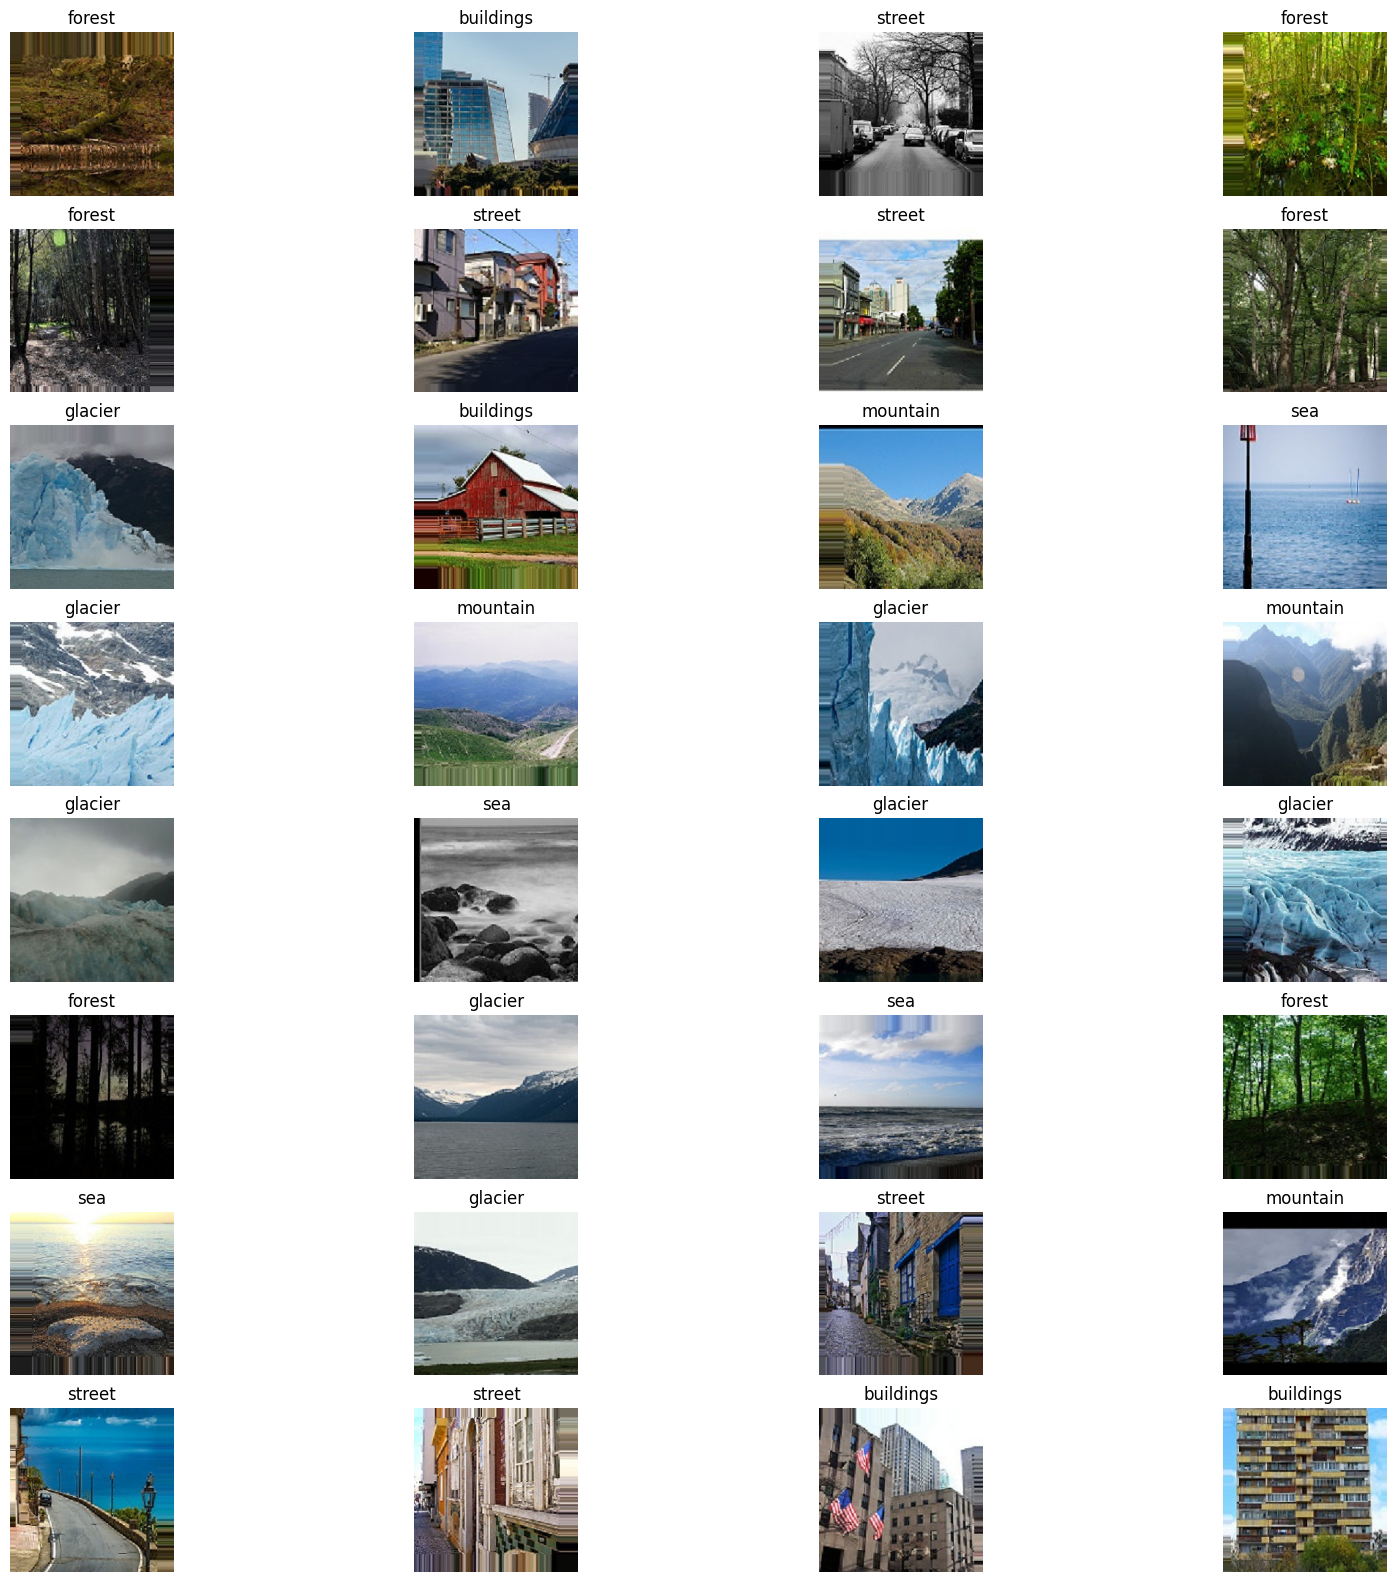

In [16]:
g_dict = train_gen.class_indices
classes = list(g_dict.keys())

images, labels = next(train_gen)  #next=batch_size


plt.figure(figsize=(20, 20))

for i in range(32):
    plt.subplot(8, 4, i + 1)

    plt.imshow(images[i])

    index = np.argmax(labels[i])  # [0,0,1,0]
    class_name = classes[index]

    plt.title(class_name)
    plt.axis('off')

plt.show()

Building Model From Scratch

In [17]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(6,activation='softmax')


])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(train_gen,validation_data=valid_gen,epochs=50)

Epoch 1/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 170s 421ms/step - accuracy: 0.5485 - loss: 1.1562 - val_accuracy: 0.6954 - val_loss: 0.7997
Epoch 2/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 162s 409ms/step - accuracy: 0.6729 - loss: 0.8808 - val_accuracy: 0.7140 - val_loss: 0.7489
Epoch 3/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 161s 406ms/step - accuracy: 0.7261 - loss: 0.7617 - val_accuracy: 0.7889 - val_loss: 0.6195
Epoch 4/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 163s 413ms/step - accuracy: 0.7547 - loss: 0.6882 - val_accuracy: 0.8024 - val_loss: 0.5601
Epoch 5/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 165s 416ms/step - accuracy: 0.7726 - loss: 0.6436 - val_accuracy: 0.7760 - val_loss: 0.6644
Epoch 6/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 166s 420ms/step - accuracy: 0.7921 - loss: 0.6041 - val_accuracy: 0.8174 - val_loss: 0.5398
Epoch 7/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 163s 413ms/step - accuracy: 0.7962 - loss: 0.5811 - val_accuracy: 0.8417 - val_loss: 0.4584
Epoch 8/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 163s 413ms/step - accuracy: 0.8028 -

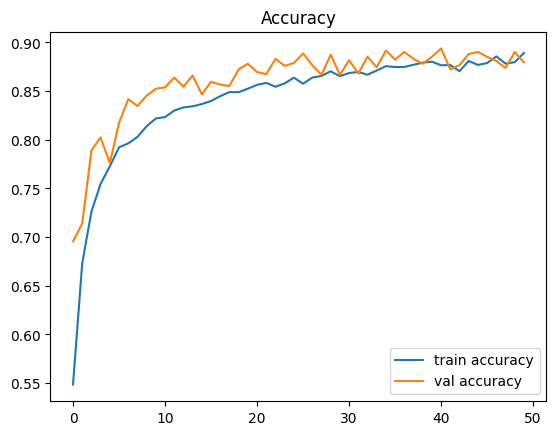

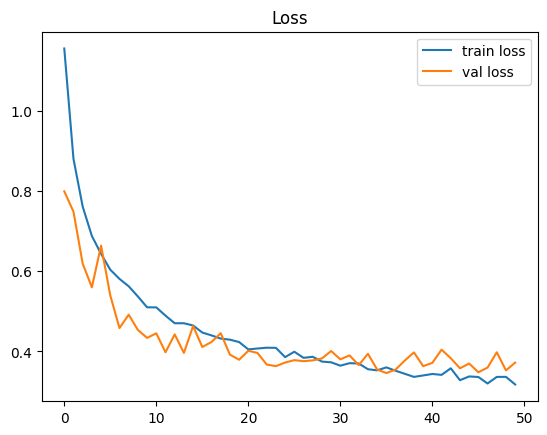

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
loss, acc = model.evaluate(test_gen)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8903 - loss: 0.3572
Test Loss: 0.35719072818756104
Test Accuracy: 0.890333354473114


Pretrained Model



In [19]:
from tensorflow.keras.applications.resnet50 import preprocess_input

In [20]:
tr_gen=ImageDataGenerator(
   preprocessing_function=preprocess_input,
    rotation_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,

)
ts_gen=ImageDataGenerator(preprocessing_function=preprocess_input)

In [21]:
train_gen=tr_gen.flow_from_dataframe(
    train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224,224),
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

valid_gen=ts_gen.flow_from_dataframe(
    valid_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True)

test_gen=ts_gen.flow_from_dataframe(
    test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)


Found 12632 validated image filenames belonging to 6 classes.
Found 1402 validated image filenames belonging to 6 classes.
Found 3000 validated image filenames belonging to 6 classes.


Feature Extraction

In [22]:
# Building Model using Feature Extraction
from tensorflow.keras import regularizers
base_model =tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False
model = Sequential([
    base_model,
    Flatten(), # Added Flatten layer here
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6,kernel_regularizer=regularizers.l2(1e-6), activation='softmax')
])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,433,670 (138.98 MB)

 Trainable params: 12,845,958 (49.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks_list = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

In [24]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
history1=model.fit(train_gen,epochs=50,validation_data=valid_gen,callbacks=callbacks_list)

Epoch 1/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 199s 467ms/step - accuracy: 0.8408 - loss: 0.5054 - val_accuracy: 0.9265 - val_loss: 0.2487 - learning_rate: 1.0000e-04
Epoch 2/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 166s 420ms/step - accuracy: 0.8809 - loss: 0.3580 - val_accuracy: 0.9244 - val_loss: 0.2554 - learning_rate: 1.0000e-04
Epoch 3/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 166s 419ms/step - accuracy: 0.8972 - loss: 0.3062 - val_accuracy: 0.9337 - val_loss: 0.2425 - learning_rate: 1.0000e-04
Epoch 4/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 166s 421ms/step - accuracy: 0.9037 - loss: 0.2847 - val_accuracy: 0.9308 - val_loss: 0.2367 - learning_rate: 1.0000e-04
Epoch 5/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 166s 420ms/step - accuracy: 0.9077 - loss: 0.2669 - val_accuracy: 0.9344 - val_loss: 0.2380 - learning_rate: 1.0000e-04
Epoch 6/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 172s 436ms/step - accuracy: 0.9129 - loss: 0.2455 - val_accuracy: 0.9315 - val_loss: 0.2444 - learning_rate: 1.0000e-04
Epoch 7/50
395/395 ━━━━━━━━━━━━━━━━━━━━ 

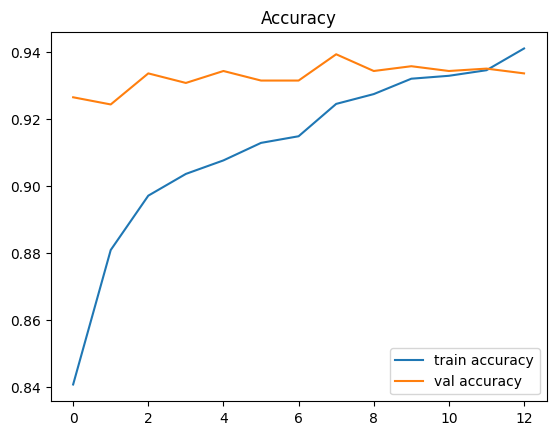

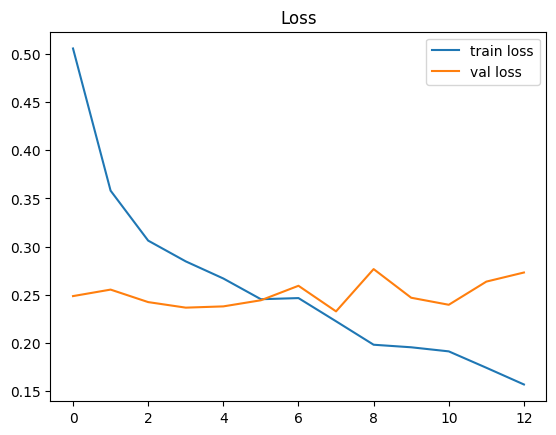

In [26]:
plt.plot(history1.history['accuracy'], label='train accuracy')
plt.plot(history1.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history1.history['loss'], label='train loss')
plt.plot(history1.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()

In [27]:
loss, acc = model.evaluate(test_gen)



print("Test Loss:", loss)
print("Test Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.9317 - loss: 0.1942
Test Loss: 0.19424115121364594
Test Accuracy: 0.9316666722297668
